In [1]:
import intake
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt 
import calendar
import cmocean as cmo
from dask.distributed import Client
import cartopy.crs as ccrs
import cartopy.feature as cft
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle

from os import environ
environ["PYTHONWARNINGS"] = "ignore"

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


In [2]:
client = Client(threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 14
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38317,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35069,Total threads: 1
Dashboard: /proxy/39149/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:40849,


In [3]:
catalog = intake.cat.access_nri
#variables = catalog.search(name='01deg_jra55v140_iaf_cycle4', frequency = '1day').unique().variable
#print(variables)

In [4]:
# --- common parameters
frequency = '1day'
snapshot_time = "2012-03-01, 00:00:00"

region_lat   = np.array([-56,-29])                    # yt_ocean,N
region_lon   = np.array([129,161]) 
region_lon   = region_lon - 360  

inset_lat   = np.array([-47.5,-46])                    # yt_ocean,N
inset_lon   = np.array([141.2,142.7]) 

In [5]:
# --- load 0.1 degree
expt_name = "01deg_jra55v140_iaf_cycle4"
var = ('usurf', 'vsurf')
ds = catalog[expt_name].search(variable=var, frequency=frequency, start_date=snapshot_time).to_dask()

# Select time / lat / lon range
ds = ds.sel(time=snapshot_time, method = 'nearest')
ds = ds.sel(yu_ocean=slice(region_lat[0], region_lat[1]))
ds = ds.sel(xu_ocean=slice(region_lon[0], region_lon[1]))
speed010 = ((ds.usurf**2+ds.vsurf**2)**0.5).compute()
ds.close()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [6]:
# --- load 0.25 degree
expt_name = "025deg_jra55_iaf_omip2_cycle6"
var = ('usurf', 'vsurf')
ds = catalog[expt_name].search(variable=var, frequency=frequency).to_dask()

# Select time / lat / lon range
ds = ds.sel(time=snapshot_time, method = 'nearest')
ds = ds.sel(yu_ocean=slice(region_lat[0], region_lat[1]))
ds = ds.sel(xu_ocean=slice(region_lon[0], region_lon[1]))
speed025 = ((ds.usurf**2+ds.vsurf**2)**0.5).compute()
ds.close()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 33.96 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [7]:
# --- load 1.0 degree
expt_name = "1deg_jra55_iaf_omip2_cycle6"
var = ('usurf', 'vsurf')
ds = catalog[expt_name].search(variable=var, frequency=frequency).to_dask()

# Select time / lat / lon range
ds = ds.sel(time=snapshot_time, method = 'nearest')
ds = ds.sel(yu_ocean=slice(region_lat[0], region_lat[1]))
ds = ds.sel(xu_ocean=slice(region_lon[0], region_lon[1]))
speed100 = ((ds.usurf**2+ds.vsurf**2)**0.5).compute()
ds.close()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


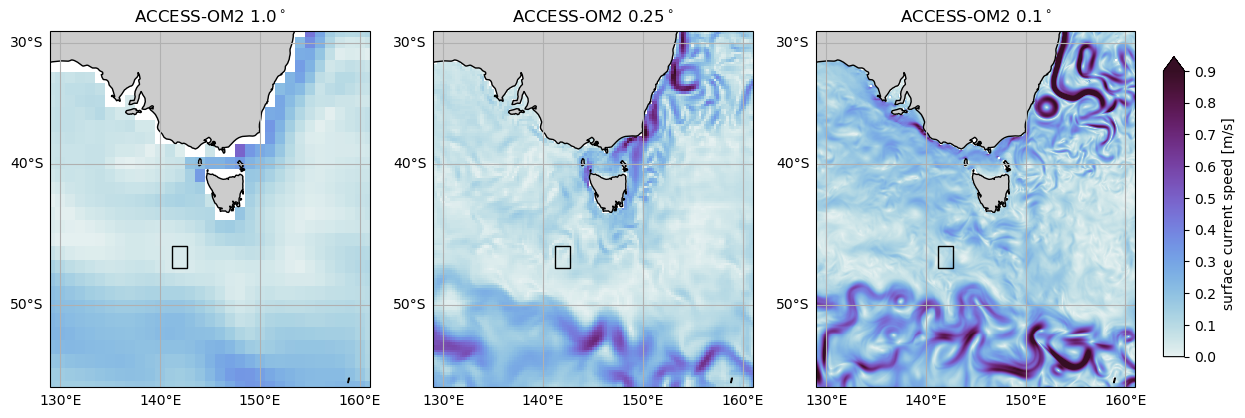

In [8]:
# Land feature
land_50m = cft.NaturalEarthFeature( "physical", "land", "50m",
    edgecolor="black",linewidth=0.5)

# Projection
projection = ccrs.Mercator(central_longitude=145, min_latitude=-55, max_latitude=-29)

datasets = [speed100, speed025, speed010]
titles = [r"ACCESS-OM2 $1.0^\circ$", r"ACCESS-OM2 $0.25^\circ$", r"ACCESS-OM2 $0.1^\circ$"]

# Figure
fig, axes = plt.subplots(1, 3, figsize=(14, 5), subplot_kw={"projection": projection},)

# Collect first plot's mappable for colorbar
mappable = None

for ax, data, title in zip(axes, datasets, titles):

    ax.set_extent([129, 161, -55, -29], crs=ccrs.PlateCarree())
    ax.add_feature(land_50m, color=[0.8, 0.8, 0.8])
    ax.coastlines(resolution="50m")
    ax.gridlines(draw_labels={"bottom": True, "left": True, "top": False, "right": False},
                 xlocs=[130, 140, 150, 160], ylocs=[-30, -40, -50],)
    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        vmin=0.0, vmax=0.9,
        cmap=cmo.cm.dense,
        add_colorbar=False,
    )

    if mappable is None:
        mappable = im

    ax.set_title(title)

    rect = Rectangle(
            (inset_lon.min(), inset_lat.min()),
            np.diff(inset_lon)[0], np.diff(inset_lat)[0],
            linewidth=1, edgecolor='k', facecolor='none', linestyle='-',
            zorder=5, transform=ccrs.PlateCarree(),
        )
    
    ax.add_patch(rect,)
    
# colorbar
cax = fig.add_axes([0.92, 0.2, 0.015, 0.6]) 
cbar = fig.colorbar(mappable, cax=cax, orientation="vertical", label = "surface current speed [m/s]", 
                    fraction = 0.03, aspect = 15,  shrink = 0.9, extend = "max")

plt.savefig("surface_currents_3panel.png", dpi=300, bbox_inches="tight")
plt.show()
